In [1]:
import pandas as pd
import numpy as np
import requests
from bs4 import BeautifulSoup
import time
import re
import unicodedata
from tqdm import tqdm
from urllib.parse import quote_plus
import nflreadpy as nfl
import pandas as pd
from rapidfuzz import process,fuzz
from pprint import pprint
import matplotlib.pyplot as plt
from nameparser import HumanName
import string

In [2]:
def clean(text):
    if pd.isna(text):
        return ""
    else:
        return (str(text).lower().strip())

def standard_name(text):
    np_name = HumanName(text)
    if len(np_name.middle) > 0:
        return f'{np_name.first} {np_name.last}'
    return f'{np_name.first} {np_name.middle} {np_name.last}'



In [3]:
def fuzz_college(text, comparison_set, threshold=80):
    if pd.isna(text):
        return text
    
    # Find the best match
    result = process.extractOne(text, comparison_set, scorer=fuzz.WRatio)
    if result:
        match, score, index = result
        # If match is good, return the matched name; 
        # otherwise, return the original college
        return match if score >= threshold else text
        
    return text



In [4]:
def score_match(my_row, nfl_row, n_w, p_w, d_w, c_w):

    # Name similarity (0–1)
    name_score = fuzz.ratio(my_row["np_name"], nfl_row["np_name"]) / 100

    # Position match
    position_score = 1.0 if my_row['position'] == nfl_row['position'] else 0.0

    # Draft year match
    draft_score = 1.0 if my_row["draft_class"] == nfl_row["draft_year"] else 0.0

    # College match
    college_score = 1.0 if (my_row["fuzz_college"] != "" and my_row["fuzz_college"] == nfl_row["college_name"]) else 0.0
    
    # Confidence
    weighted_confidence = n_w * name_score + p_w * position_score +  d_w * draft_score + c_w * college_score
    
    return weighted_confidence

In [5]:
def compare_columns(column_1, column_2):
    col_1_set = set(column_1.dropna().str.strip().str.lower())
    col_2_set = set(column_2.dropna().str.strip().str.lower())

    overlap = col_1_set.intersection(col_2_set)
    missing = col_1_set.difference(col_2_set)

    size_col_1 =  len(column_1)
    count_in_col_2 = column_1.str.strip().str.lower().isin(column_2.str.strip().str.lower()).sum()

    print(f'Column 1 has {len(col_1_set)} unique values. {len(overlap)} exist in Column 2')
    print(f'{count_in_col_2} out of {size_col_1} in Column 1 exist in Column 2\n\n')
    print('Missing Values')
    pprint(missing)
          


In [6]:
def match_player(row, players_names, players_records, n_w, p_w, d_w, c_w, top_k=5 ):

    candidates = process.extract(
        row["np_name"],
        players_names,
        scorer=fuzz.ratio,
        limit=top_k
    )

    best_match = None
    best_score = -1

    for name_match, _, idx in candidates:
        nfl_row = players_records[idx]
        score = score_match(row, nfl_row, n_w, p_w, d_w, c_w)

        if score > best_score:
            best_score = score
            best_match = nfl_row

    return pd.Series({
        "matched_name": best_match["display_name"] if best_match else None,
        "matched_draft_year": best_match["draft_year"] if best_match else None,
        "matched_college": best_match["college_name"] if best_match else None,
        "matched_position": best_match["position"] if best_match else None,
        "nfl_versed_player_id" : best_match['pfr_id'] if best_match else None,
        "confidence": best_score
    })

In [7]:

# Load the players crosswalk — has pfr_id, draft year, name, position, college, etc.
players = nfl.load_players().to_pandas()

In [8]:
display(players.columns)

Index(['gsis_id', 'display_name', 'common_first_name', 'first_name',
       'last_name', 'short_name', 'football_name', 'suffix', 'esb_id',
       'nfl_id', 'pfr_id', 'pff_id', 'otc_id', 'espn_id', 'smart_id',
       'birth_date', 'position_group', 'position', 'ngs_position_group',
       'ngs_position', 'height', 'weight', 'headshot', 'college_name',
       'college_conference', 'jersey_number', 'rookie_season', 'last_season',
       'latest_team', 'status', 'ngs_status', 'ngs_status_short_description',
       'years_of_experience', 'pff_position', 'pff_status', 'draft_year',
       'draft_round', 'draft_pick', 'draft_team'],
      dtype='str')

In [9]:
display(players['position'].unique())
display(players['college_name'].unique())

<ArrowStringArray>
[ 'NT',  'RB',  'LB',   'K',  'WR',  'DE',   'S',  'DB',  'FS', 'OLB',  'TE',
   'G',  'CB',  'OT',  'DT',   'C', 'MLB',  'QB',  'LS', 'SAF',  'DL',   'P',
 'ILB',  'OL',  'FB']
Length: 25, dtype: str

<ArrowStringArray>
[                                                  'UNLV',
                                             'Pittsburgh',
                                            'Wake Forest',
                 'California State-Fullerton; Washington',
                                              'Wisconsin',
                                         'Boston College',
                                                'Fordham',
                                               'Nebraska',
                                       'Washington State',
                                              'Mars Hill',
 ...
                             'N.C. State; Fairmont State',
                   'Fort Lewis College; Cerritos College',
                                 'University of La Verne',
           'Oklahoma State; NW Missouri State University',
                         'Kansas State; Butler County JC',
 'Louisiana-Monroe; University of Arkansas at Pine Bluff',
                        'Mississ

In [10]:
# Read scraped combine data
df_nfl_combine = pd.read_csv("nfl_combine_data.csv")
df = df_nfl_combine.copy()

df.shape


(8707, 17)

In [11]:
df.columns

Index(['player_name', 'player_id', 'player_url', 'draft_class', 'position',
       'college', 'weight_lbs', 'height_in', 'arm_length_in', 'hand_size_in',
       'yard_40_dash_sec', 'yard_10_split_sec', 'cone_drill_sec',
       'yard_20_shuttle_sec', 'vertical_jump_in', 'broad_jump_in',
       'bench_press_reps'],
      dtype='str')

In [12]:
print(set(players['college_name'].unique()))

{'', 'Western Carolina', 'USC; Oklahoma; Santa Monica; East Los Angeles College', 'Purdue; Coffeyville CC', 'Illinois; San Bernardino Valley', 'Oregon; Alabama', 'N.C. State; Kentucky', 'DePauw University', 'Indiana; UAB', 'Fresno State; Hawaii', 'Utah State; Blinn College', 'Illinois State; Wisconsin', 'Colorado State; Nevada', 'UNLV; Moorpark College', 'Missouri; Tennessee', 'California State-Fullerton', 'Clemson; Northeast Oklahoma', 'San Diego State; Rancho Santiago Community Coll', 'Oregon State; College of the Canyons', 'Eastern Kentucky; LSU', 'Portland State; Arizona', 'North Alabama; Florida', 'Iowa State', 'Salisbury State University', 'Miami; Oklahoma', 'Eastern Illinois; Chabot College', 'Illinois; Ventura', 'Washington State; Iowa Western CC', 'San Jose State; Monterey Peninsula', 'California; Penn State', 'Colorado; Jackson State University', 'Georgia; California State - Long Beach', 'Louisiana-Lafayette; Glendale Community College', 'Tennessee; Itawamba JC', 'Tulane; TCU

### Columns standardized and filtered

In [13]:
# At least 3 seasons of data 

df = df[df['draft_class'] <= 2023] #2024, 2025, 2026 
players = players[players['draft_year'] <= 2023]

# Strip and clean college names + drop NAs

df['college'] = df['college'].apply(clean)
df = df.dropna(subset=['college'])
players['college_name'] = players['college_name'].apply(clean)
players = players.dropna(subset=['college_name'])

# Strip and clean position names

df['position'] = df['position'].apply(clean)
players['position'] = players['position'].apply(clean)

# Strip and clean player names
# Remvoe suffixes

df['player_name'] =  df['player_name'].apply(clean)
players['display_name'] =  players['display_name'].apply(clean)

### Standardize Colleges in csv

Colleges that are ambigious or that do not have an entry in players dataset will be removed

In [14]:
# Find not matching universities/colleges

compare_columns(df['college'], players['college_name'])



Column 1 has 352 unique values. 238 exist in Column 2
7209 out of 7751 in Column 1 exist in Column 2


Missing Values
{'albany state',
 'arkansas pine bluff',
 'arkansas-pine bluff',
 'ashland',
 'belhaven',
 'bethune-cookman',
 'bowie state',
 'cal',
 'cal davis',
 'cal poly',
 'catawba',
 'central connecticut state',
 'central florida',
 'central washington',
 'charleston southern',
 'chattanooga',
 'cheyney',
 'citadel',
 'clarion',
 'clark atlanta',
 'colorado state-pueblo',
 'concordia (mn)',
 'concordia-st. paul',
 'culver-stockton',
 'dixie state',
 'dubuque',
 'ecu',
 'emporia state',
 'fayetteville state',
 'fiu',
 'fort hays state',
 'fort valley state (ga)',
 'glenville state',
 'grand valley state',
 'gustavus adolphus',
 'harding',
 'hartwick',
 "hawai'i",
 'indiana (pa)',
 'jackson state',
 'kentucky state',
 'kutztown (pa)',
 'lafayette',
 'lane',
 'lehigh',
 'lenoir-rhyne',
 'lindenwood',
 'louisiana',
 'malone university (ohio)',
 'marian (in)',
 'massachusetts',
 'mer

In [15]:
# Fuzzy match on colleges

unique_df_colleges = df['college'].dropna().unique().tolist()
players_college_list = list(set(players['college_name'])) # Use for fuzzmatching

mapping = {}
for college in unique_df_colleges:
    if pd.isna(college):
        mapping[college] = college
        continue

    match, score, _ = process.extractOne(
        college,
        players_college_list,
        scorer=fuzz.WRatio
    )

    if score >= 80:
        mapping[college] = match
    else:
        mapping[college] = college

df['fuzz_college'] = df['college'].replace(mapping)

In [16]:
# Find not matching universities/colleges
compare_columns(df['fuzz_college'], players['college_name'])


Column 1 has 305 unique values. 288 exist in Column 2
7604 out of 7751 in Column 1 exist in Column 2


Missing Values
{'belhaven',
 'cheyney',
 'concordia-st. paul',
 'culver-stockton',
 'dubuque',
 'ecu',
 'fiu',
 'hartwick',
 'marian (in)',
 'massachusetts',
 'merrimack',
 'ole miss',
 'stony brook',
 'tiffin',
 'utep',
 'utsa',
 'whitworth'}


In [17]:
drop_colleges = ['belhaven',
 'cheyney',
 'concordia-st. paul',
 'culver-stockton',
 'dubuque',
 'ecu',
 'fiu',
 'hartwick',
 'marian (in)',
 'massachusetts',
 'merrimack',
 'ole miss',
 'stony brook',
 'tiffin',
 'utep',
 'utsa',
 'whitworth']

df = df[~df['college'].isin(drop_colleges)]

### Standardize positions

In [18]:
# Standardize positions

print(sorted(list(set(players['position'].unique()))))
print(sorted(list(set(df['position'].unique()))))

['c', 'cb', 'db', 'de', 'dl', 'dt', 'fb', 'fs', 'g', 'ilb', 'k', 'lb', 'ls', 'mlb', 'nt', 'ol', 'olb', 'ot', 'p', 'qb', 'rb', 's', 'saf', 'te', 'wr']
['3-4 outside linebacker', 'athlete', 'cornerback', 'defensive back', 'defensive line', 'defensive tackle', 'edge defender', 'fullback', 'halfback', 'inside linebacker', 'interior defensive line', 'kicker', 'linebacker', 'long snapper', 'nose tackle', 'offensive center', 'offensive guard', 'offensive line', 'offensive tackle', 'one-gap defensive end', 'outside linebacker', 'punter', 'quarterback', 'safety', 'tight end', 'wide receiver']


Positions that are not core/standard across all types of schemes will be filtered out. Positions that cannot be aligned across both datasets will be filtered out

Removed
* Edge Defender
* Inside Lineback
* Safety
* Interior Defensive Line
* 3-4 Outside Lineback
* One-gap defensive end
* Athelete

In [19]:
position_map = {
    "offensive center": "c",
    "cornerback": "cb",
    "defensive back": "db",
    "edge defender": "remove",
    "defensive line": "dl",
    "defensive tackle": "dt",
    "fullback": "fb",
    "safety": "remove",
    "offensive guard": "g",
    "inside linebacker": "remove",
    "kicker": "k",
    "linebacker": "lb",
    "long snapper": "ls",
    "offensive line": "ol",
    "outside linebacker": "olb",
    "offensive tackle": "ot",
    "punter" :"p",
    "quarterback": "qb",
    "halfback":"rb",
    "safety": "remove",
    "tight end": "te",
    "wide receiver": "wr",
    "nose tackle": "nt",
    "interior defensive line": "remove",
    "3-4 outside linebacker":"remove",
    "one-gap defensive end": "remove",
    'athlete' : 'remove'
}

In [20]:
df['position'] = df['position'].apply(clean)
df['position'] = df['position'].map(position_map).apply(clean).fillna(df['position'])
df = df[df['position'] != 'remove']

In [21]:
compare_columns(df['position'], players['position'])

Column 1 has 19 unique values. 19 exist in Column 2
6038 out of 6038 in Column 1 exist in Column 2


Missing Values
set()


### Standardize Names in CSV for Fuzzy

In [22]:
df["players_with_same_name"] = np.where(df["player_name"].map(df["player_name"].value_counts()) > 1,
    "Y",
    "N")

df_single_names = df[df["players_with_same_name"] == "N"].copy()
df_multi_names  = df[df["players_with_same_name"] == "Y"].copy()

print(f"Players with no duplicate names:    {len(df_single_names)}")
print(f"Players with duplicate names: {len(df_multi_names)}")

Players with no duplicate names:    5891
Players with duplicate names: 147


In [23]:
df['np_name'] = df['player_name'].apply(standard_name)
players['np_name'] = players['display_name'].apply(standard_name)

In [24]:
# make lookup easier 

players_records = players.to_dict("records")
players_names = players["np_name"].tolist()

Dataset will be aligned based on position, draft_year, name and college in order of highest weight to lowest  

* Positions - Standard positions, it is rare for players to switch positions. So we place the highest weight on that.
* Draft_year - Players drafted typically have cleaner data
* Name - Not a lot of shared names within our dataset
* College - college can be ambigious so we place the least focus on that


In [25]:
# Condition matching weights

name_weight  = 13.33
position_weight = 53.33 
draft_weight = 26.67
college_weight = 6.67

In [26]:
results = df[['player_name', 'np_name', 'player_id', 'draft_class','position','fuzz_college']].apply(match_player, axis=1, args=(players_names, players_records, name_weight, position_weight, draft_weight, college_weight))
df_matched = pd.concat([df[['player_name', 'player_id', 'draft_class','position','fuzz_college']], results], axis=1)

In [27]:
display(df_matched.columns)
display(df_matched.head(50))

Index(['player_name', 'player_id', 'draft_class', 'position', 'fuzz_college',
       'matched_name', 'matched_draft_year', 'matched_college',
       'matched_position', 'nfl_versed_player_id', 'confidence'],
      dtype='str')

,player_name,player_id,draft_class,position,fuzz_college,matched_name,matched_draft_year,matched_college,matched_position,nfl_versed_player_id,confidence
0,a'shawn robinson,ashawnrobinson2016,2016,dt,alabama,a'shawn robinson,2016.0,alabama,dt,RobiAS00,100.000000
1,a.c. leonard,acleonard2014,2014,te,tennessee state,rick leonard,2018.0,florida state,ot,LeonRi00,10.253846
3,a.j. cann,ajcann2015,2015,g,south carolina,a.j. cann,2015.0,south carolina,g,CannA.00,100.000000
4,a.j. derby,ajderby2015,2015,te,arkansas,a.j. derby,2015.0,arkansas; coffeyville cc; iowa,te,DerbA.00,93.330000
5,a.j. edds,ajedds2010,2010,olb,iowa,a.j. edds,2010.0,iowa,lb,EddsA.99,46.670000
6,a.j. epenesa,ajepenesa2020,2020,dl,iowa,a.j. epenesa,2020.0,iowa,de,EpenAJ00,46.670000
7,a.j. green,ajgreen2020,2020,cb,oklahoma state,d.j. reed,2018.0,kansas state; cerritos college; fresno state,cb,ReedD.00,63.486190
8,a.j. green,ajgreen2011,2011,wr,georgia,a.j. green,2011.0,georgia,wr,GreeA.00,100.000000
9,a.j. greene,ajgreene2012,2012,ot,auburn,a.j. greene,1989.0,wake forest,db,GreeA.20,13.330000
10,a.j. hawk,ajhawk2006,2006,olb,ohio state,a.j. hawk,2006.0,ohio state,lb,HawkA.20,46.670000


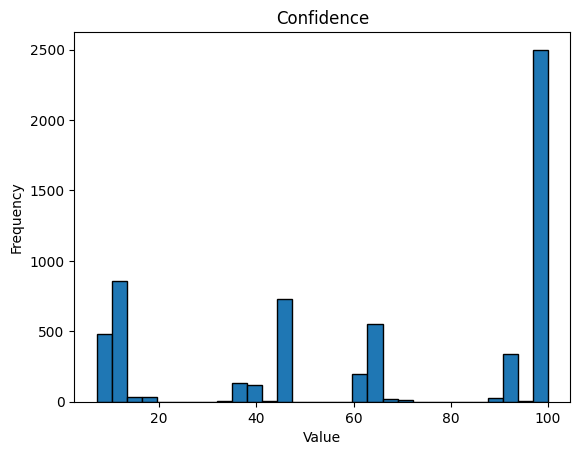

In [28]:
df_matched['confidence'].hist(bins=30, edgecolor='black', grid=False)

plt.title('Confidence')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()

In [29]:
confidence_conditions = [df_matched['confidence'] < 25, 
                        df_matched['confidence'] < 50,
                        df_matched['confidence'] < 75,
                        df_matched['confidence'] < 100]
confidence_results = ['low', 'low-medium', 'medium', 'high']

df_matched['confidence_label'] = np.select(confidence_conditions, confidence_results, default='perfect')

In [30]:
display(df_matched.head())

,player_name,player_id,draft_class,position,fuzz_college,matched_name,matched_draft_year,matched_college,matched_position,nfl_versed_player_id,confidence,confidence_label
0,a'shawn robinson,ashawnrobinson2016,2016,dt,alabama,a'shawn robinson,2016.0,alabama,dt,RobiAS00,100.000000,perfect
1,a.c. leonard,acleonard2014,2014,te,tennessee state,rick leonard,2018.0,florida state,ot,LeonRi00,10.253846,low
3,a.j. cann,ajcann2015,2015,g,south carolina,a.j. cann,2015.0,south carolina,g,CannA.00,100.000000,perfect
4,a.j. derby,ajderby2015,2015,te,arkansas,a.j. derby,2015.0,arkansas; coffeyville cc; iowa,te,DerbA.00,93.330000,high
5,a.j. edds,ajedds2010,2010,olb,iowa,a.j. edds,2010.0,iowa,lb,EddsA.99,46.670000,low-medium


We only use records that have a high confidence. This dramatically drops our sample size, but it is still ,much bigger than samples done in other studies

In [31]:
df_matched_filter = df_matched[(df_matched['confidence_label'] == 'high') | (df_matched['confidence_label'] == 'perfect')]
df_matched_filter = df_matched_filter[['player_name', 'position', 'draft_class', 'nfl_versed_player_id', 'player_id']] # Remove extra columns
# df_final_player_records  = 

In [32]:
display(df_matched_filter.head())

,player_name,position,draft_class,nfl_versed_player_id,player_id
0,a'shawn robinson,dt,2016,RobiAS00,ashawnrobinson2016
3,a.j. cann,g,2015,CannA.00,ajcann2015
4,a.j. derby,te,2015,DerbA.00,ajderby2015
8,a.j. green,wr,2011,GreeA.00,ajgreen2011
12,a.j. jenkins,wr,2012,JenkA.00,ajjenkins2012


In [33]:
df_nfl_combine_stats = pd.merge(df_nfl_combine, df_matched_filter, how = 'inner', left_on = ['player_id'], right_on = ['player_id'])
nfl_combine_columns_to_drop  = [
    'player_name_x',
    'player_id',
    'draft_class_x',
    'position_x',
    'draft_class_y',
    'college',
    'player_url'
]
df_nfl_combine_stats = df_nfl_combine_stats.drop(columns=nfl_combine_columns_to_drop)

nfl_combine_columns_to_rename = {
    'player_name_y':'player_name',
    'nfl_versed_player_id': 'pfr_id',
    'position_y':'position'
}

df_nfl_combine_stats = df_nfl_combine_stats.rename(columns=nfl_combine_columns_to_rename)
df_nfl_combine_stats = df_nfl_combine_stats[['player_name','pfr_id','position','weight_lbs','height_in','arm_length_in','hand_size_in','yard_40_dash_sec',
                                             'yard_10_split_sec','cone_drill_sec','yard_20_shuttle_sec','vertical_jump_in','broad_jump_in','bench_press_reps']]
# df_nfl_combine_stats.rename
display(df_nfl_combine_stats.head())
display(df_nfl_combine_stats.columns)

,player_name,pfr_id,position,weight_lbs,height_in,arm_length_in,hand_size_in,yard_40_dash_sec,yard_10_split_sec,cone_drill_sec,yard_20_shuttle_sec,vertical_jump_in,broad_jump_in,bench_press_reps
0,a'shawn robinson,RobiAS00,dt,307.0,72.0,34.500,10.50,5.20,1.78,7.80,4.74,26.0,106.0,22.0
1,a.j. cann,CannA.00,g,313.0,72.0,32.625,10.25,NaN,NaN,NaN,NaN,NaN,NaN,26.0
2,a.j. derby,DerbA.00,te,255.0,72.0,30.500,9.50,NaN,NaN,NaN,NaN,NaN,NaN,15.0
3,a.j. green,GreeA.00,wr,211.0,72.0,34.375,9.25,4.48,1.55,6.91,4.21,34.5,126.0,18.0
4,a.j. jenkins,JenkA.00,wr,190.0,72.0,32.750,9.50,4.39,NaN,6.73,4.12,38.0,124.0,12.0


Index(['player_name', 'pfr_id', 'position', 'weight_lbs', 'height_in',
       'arm_length_in', 'hand_size_in', 'yard_40_dash_sec',
       'yard_10_split_sec', 'cone_drill_sec', 'yard_20_shuttle_sec',
       'vertical_jump_in', 'broad_jump_in', 'bench_press_reps'],
      dtype='str')

In [34]:
df_nfl_combine_stats = pd.merge(df_nfl_combine, df_matched_filter, how = 'inner', left_on = ['player_id'], right_on = ['player_id'])
nfl_combine_columns_to_drop  = [
    'player_name_x',
    'player_id',
    'draft_class_x',
    'position_x',
    'draft_class_y',
    'college',
    'player_url'
]
df_nfl_combine_stats = df_nfl_combine_stats.drop(columns=nfl_combine_columns_to_drop)

nfl_combine_columns_to_rename = {
    'player_name_y':'player_name',
    'nfl_versed_player_id': 'pfr_id',
    'position_y':'position'
}

df_nfl_combine_stats = df_nfl_combine_stats.rename(columns=nfl_combine_columns_to_rename)
df_nfl_combine_stats = df_nfl_combine_stats[['player_name','pfr_id','position','weight_lbs','height_in','arm_length_in','hand_size_in','yard_40_dash_sec',
                                             'yard_10_split_sec','cone_drill_sec','yard_20_shuttle_sec','vertical_jump_in','broad_jump_in','bench_press_reps']]
# df_nfl_combine_stats.rename
display(df_nfl_combine_stats.head())
display(df_nfl_combine_stats.columns)

,player_name,pfr_id,position,weight_lbs,height_in,arm_length_in,hand_size_in,yard_40_dash_sec,yard_10_split_sec,cone_drill_sec,yard_20_shuttle_sec,vertical_jump_in,broad_jump_in,bench_press_reps
0,a'shawn robinson,RobiAS00,dt,307.0,72.0,34.500,10.50,5.20,1.78,7.80,4.74,26.0,106.0,22.0
1,a.j. cann,CannA.00,g,313.0,72.0,32.625,10.25,NaN,NaN,NaN,NaN,NaN,NaN,26.0
2,a.j. derby,DerbA.00,te,255.0,72.0,30.500,9.50,NaN,NaN,NaN,NaN,NaN,NaN,15.0
3,a.j. green,GreeA.00,wr,211.0,72.0,34.375,9.25,4.48,1.55,6.91,4.21,34.5,126.0,18.0
4,a.j. jenkins,JenkA.00,wr,190.0,72.0,32.750,9.50,4.39,NaN,6.73,4.12,38.0,124.0,12.0


Index(['player_name', 'pfr_id', 'position', 'weight_lbs', 'height_in',
       'arm_length_in', 'hand_size_in', 'yard_40_dash_sec',
       'yard_10_split_sec', 'cone_drill_sec', 'yard_20_shuttle_sec',
       'vertical_jump_in', 'broad_jump_in', 'bench_press_reps'],
      dtype='str')

In [46]:
df_player_stats = df_nfl_combine_stats.copy()

df_player_stats_columns_to_keep  = ['pfr_id']
df_player_stats = df_player_stats[df_player_stats_columns_to_keep]
df_player_stats = pd.merge(df_player_stats, players, how = 'inner', left_on = 'pfr_id', right_on = 'pfr_id', suffixes=['','_y'])

df_player_stats_columns_to_keep.append('gsis_id')
df_player_stats = df_player_stats[df_player_stats_columns_to_keep]
# ['player_name','pfr_id','position']

In [47]:
df_player_stats.head()

,pfr_id,gsis_id
0,RobiAS00,00-0032889
1,CannA.00,00-0032255
2,DerbA.00,00-0031609
3,GreeA.00,00-0027942
4,JenkA.00,00-0029654


Extract player data from the lowest draft season to 3 years after the highest draft season

In [48]:
min_draft_season = df['draft_class'].min()
max_draft_season = df['draft_class'].max()
print(min_draft_season)
print(max_draft_season)

KeyError: 'draft_class'

In [49]:
frames = []
for season in range(min_draft_season, max_draft_season + 1):
    print(f"Loading {season}...")
    try:
        df = nfl.load_player_stats([season]).to_pandas()
        frames.append(df)
        time.sleep(1)
    except ConnectionError as e:
        print(f"Skipping {season}: {e}")

player_stats = pd.concat(frames, ignore_index=True)

Loading 1999...
Loading 2000...
Loading 2001...
Loading 2002...
Loading 2003...
Loading 2004...
Loading 2005...
Loading 2006...
Loading 2007...
Loading 2008...
Loading 2009...
Loading 2010...
Loading 2011...
Loading 2012...
Loading 2013...
Loading 2014...
Loading 2015...
Loading 2016...
Loading 2017...
Loading 2018...
Loading 2019...
Loading 2020...
Loading 2021...
Loading 2022...
Loading 2023...


In [50]:
df_player_stats = pd.merge(df_player_stats, player_stats, how = 'left', left_on = 'gsis_id', right_on ='player_id', suffixes=['', '_y'])

In [51]:
display(df_player_stats.head())



,pfr_id,gsis_id,player_id,player_name,player_display_name,position,position_group,headshot_url,season,week,...,pat_blocked,pat_pct,gwfg_made,gwfg_att,gwfg_missed,gwfg_blocked,gwfg_distance,fantasy_points,fantasy_points_ppr,game_id
0,RobiAS00,00-0032889,00-0032889,A.Robinson,A'Shawn Robinson,DE,DL,https://static.www.nfl.com/image/upload/f_auto...,2016.0,1.0,...,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
1,RobiAS00,00-0032889,00-0032889,A.Robinson,A'Shawn Robinson,DE,DL,https://static.www.nfl.com/image/upload/f_auto...,2016.0,2.0,...,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
2,RobiAS00,00-0032889,00-0032889,A.Robinson,A'Shawn Robinson,DE,DL,https://static.www.nfl.com/image/upload/f_auto...,2016.0,3.0,...,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
3,RobiAS00,00-0032889,00-0032889,A.Robinson,A'Shawn Robinson,DE,DL,https://static.www.nfl.com/image/upload/f_auto...,2016.0,4.0,...,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
4,RobiAS00,00-0032889,00-0032889,A.Robinson,A'Shawn Robinson,DE,DL,https://static.www.nfl.com/image/upload/f_auto...,2016.0,5.0,...,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
